<a href="https://colab.research.google.com/github/ICam99/cdsi2025/blob/main/practica4/Practica4_IgnacioC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 4: Sensado de señales fisiológicas

Comenzamos instalando heartpy y neurokit2

In [ ]:
!pip install heartpy

Se instala NeuroKit2 para extracción de características usando Kubios

In [ ]:
!pip install neurokit2

Importamos las librerías que utilizaremos para la práctica

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import heartpy as hp
import neurokit2 as nk

# Filtro Savistsky-Golay
from scipy.signal import savgol_filter

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_class_weight

# SMOTE es una librería para realizar Over-Sampling (para aumento de datos)
from imblearn.over_sampling import SMOTE

Cargamos los datos con los que trabajaremos.

In [ ]:
data = pd.read_csv("datos/Heart_Rate_VR_Data.csv")

## Análisis Exploratorio

In [ ]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user                 124 non-null    object
 1   sex                  124 non-null    int64 
 2   VR experience        124 non-null    int64 
 3   heart/vertigo issue  124 non-null    int64 
 4   time                 124 non-null    object
 5   event                124 non-null    object
 6   fear level           124 non-null    int64 
 7   hear rate file       124 non-null    object
dtypes: int64(4), object(4)
memory usage: 7.9+ KB
None
              sex  VR experience  heart/vertigo issue  fear level
count  124.000000     124.000000           124.000000  124.000000
mean     0.653226       0.669355             0.258065    0.862903
std      0.477874       0.472354             0.439345    1.398807
min      0.000000       0.000000             0.000000    0.000000
25%      0.000000    

Comenzando con info() y describe(), podemos ver que nuestro dataset tiene 124 filas. Vemos que en su mayoría los participantes son hombres, ya que el .csv guarda los hombres con 1 y mujeres con 0, y la media es mayor a 0.5.
Asímismo, la mayoría de los participantes cuentan con experiencia previa en realidad virtual. Alrededor de un cuarto de los participantes tienen problemas de vértigo o condiciones del corazón. El nivel de miedo va desde 0 hasta 5, y la mayoría de los datos tienden a 0.

## Limpieza y Extracción de Datos

Dado que en el dataset, el tiempo tiene formato m:ss (minutos:segundos, e.g. 0:00), definiremos una función que convierte el tiempo a número de segundos (por ejemplo, 1:30 se convertiría a 90).

In [ ]:
def time_to_seconds(time_str):
    minutes, seconds = map(int, time_str.split(':'))
    return minutes * 60 + seconds

Definimos ahora una función para extraer características con Kubios, y funciones para limpieza de datos previa.

In [ ]:
# Función para deshacernos de los outliers (en este caso, valores menores a 40 o mayores a 180 BPM)
def remove_outliers(hr_data, lower_bound=40, upper_bound=180):
    hr_data = np.clip(hr_data, lower_bound, upper_bound)
    return hr_data

# Función que aplica el filtro Savitsky-Golay para suavizar señales (disminuir ruido)
def apply_savitzky_golay(hr_data, window_length=7, polyorder=3):
    smoothed_hr = savgol_filter(hr_data, window_length, polyorder)
    return smoothed_hr

# Función de suavizado utilizando filtro de media móvil
def smooth_hr_data(hr_data, window_size=5):
    if window_size % 2 == 0:
        window_size += 1
    smoothed_hr = np.convolve(hr_data, np.ones(window_size) / window_size, mode='same')
    return smoothed_hr

Para la extracción de características con Kubios, utilizaremos el tiempo para separar los valores por evento.

In [ ]:
def extract_kubios_features(time_series, start_time, end_time):
    # Se filtran los datos basándose en tiempo de inicio y fin de cada evento
    filtered_data = time_series[(time_series['timestamp'] >= start_time) & (time_series['timestamp'] <= end_time)]

    try:
        # 1. Se extraen intervalos RR
        rri = filtered_data['hr'].to_numpy()

        # 2. Se convierten los intervalos RR en índices de picos
        peaks = nk.intervals_to_peaks(rri)

        # 3. Se convierten también en BPM
        hr = 60000 / rri

        # 4. Se aplican los filtros por medio de las funciones previamente definidas
        hr = remove_outliers(hr, lower_bound=40, upper_bound=180)
        hr = apply_savitzky_golay(hr, window_length=7, polyorder=3)
        hr = smooth_hr_data(hr, window_size=5)

        # 5. Se analizan los resultados de HRV utilizando Kubios
        hrv_results = nk.hrv_time(peaks, sampling_rate=1000, method="kubios")

    #Manejo de excepciones
    except FileNotFoundError:
        print(f"Error: File not found at path. Returning NaN values.")
        hrv_results = pd.DataFrame(np.nan, index=[0], columns=nk.hrv_time(np.array([1, 2]), sampling_rate=1000.0, method="kubios").columns)
        return hrv_results

    except Exception as e:
        print(f"Error processing file. Error: {e}. Returning NaN values.")
        hrv_results = pd.DataFrame(np.nan, index=[0], columns=nk.hrv_time(np.array([1, 2]), sampling_rate=1000.0, method="kubios").columns)
        return hrv_results

    return hrv_results

Con las funciones que hemos definido, podemos ahora guardar los datos extraídos por Kubios en un nuevo dataframe.

In [ ]:
# Convertimos la columna de tiempo a segundos
data['time_seconds'] = data['time'].apply(time_to_seconds)

all_event_features = []

for index, row in data.iterrows():
    user_id = row['user']
    start_time = row['time_seconds']

    # Se cargan los datos de cada archivo .txt
    hr_file_path = "datos/" + str(row['hear rate file'])
    hr_data = np.loadtxt(hr_file_path)

    # Se crean series de tiempo para los datos
    time_series = pd.DataFrame({'timestamp': np.arange(start_time, start_time + len(hr_data), 1),
                                 'hr': hr_data})

    # Se determina el tiempo de finalización del evento tomando el tiempo de inicio del siguiente evento
    next_event_index = index + 1
    if next_event_index < len(data) and data.loc[next_event_index, 'user'] == user_id:
        end_time = data.loc[next_event_index, 'time_seconds'] - 1
    else:
        end_time = time_series['timestamp'].iloc[-1]

    # Se extraen características para el evento específico
    event_features = extract_kubios_features(time_series, start_time, end_time)

    # Se añade el resto de la información
    event_features['user'] = user_id
    event_features['event_type'] = row['event']
    event_features['event_start_time'] = start_time
    event_features['event_end_time'] = end_time
    event_features['sex'] = row['sex']
    event_features['VR experience'] = row['VR experience']
    event_features['heart/vertigo issue'] = row['heart/vertigo issue']
    event_features['fear level'] = row['fear level']

    all_event_features.append(event_features)

# Creamos nuestro DataFrame
event_features_df = pd.concat(all_event_features, ignore_index=True)

Visualizamos ahora nuestro dataframe generado.

In [ ]:
event_features_df

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_HTI,HRV_TINN,user,event_type,event_start_time,event_end_time,sex,VR experience,heart/vertigo issue,fear level
0,766.928571,60.930320,NaN,NaN,NaN,NaN,NaN,NaN,41.377860,41.651981,...,11.200000,226.5625,ignacio,relax,0,55,1,1,0,0
1,766.880000,63.557026,NaN,NaN,NaN,NaN,NaN,NaN,41.448764,41.690745,...,10.000000,242.1875,ignacio,VR on,56,105,1,1,0,0
2,730.294118,72.733903,NaN,NaN,NaN,NaN,NaN,NaN,41.734278,42.492352,...,8.500000,23.4375,ignacio,going up in the elevator,106,122,1,1,0,0
3,752.500000,68.859761,NaN,NaN,NaN,NaN,NaN,NaN,45.095372,45.711594,...,9.333333,140.6250,ignacio,open elevator doors,123,150,1,1,0,0
4,765.716981,62.098674,NaN,NaN,NaN,NaN,NaN,NaN,41.830933,42.219007,...,10.600000,140.6250,ignacio,start walk,151,203,1,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,767.725806,61.012272,NaN,NaN,NaN,NaN,NaN,NaN,30.902544,31.114244,...,6.888889,148.4375,luis,start walk,183,244,1,0,0,3
120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,luis,end walk,245,245,1,0,0,3
121,764.409091,61.582459,NaN,NaN,NaN,NaN,NaN,NaN,31.513855,31.758252,...,7.333333,156.2500,luis,elevator,246,311,1,0,0,0
122,760.630435,59.529398,NaN,NaN,NaN,NaN,NaN,NaN,26.628306,26.928600,...,7.666667,148.4375,luis,start red light,312,357,1,0,0,1


Dado que estamos trabajando con eventos específicos, y que estos eventos duran solo unos pocos segundos, no hay suficiente duración para poder generar varios de los datos que normalmente extrae Kubios. Aún así se generan muchos datos útiles, y consideré que era mejor para el análisis mantener la clasificación por eventos. Así que ahora manejaremos los datos nulos.

In [ ]:
# Calculamos porcentaje de datos nulos por columna
null_percentage = event_features_df.isnull().sum() * 100 / len(event_features_df)

# Dejamos como límite el 50% de los datos (si más de la mitad de los datos son nulos, eliminamos la columna)
threshold = 50

columns_to_drop = null_percentage[null_percentage > threshold].index

event_features_df = event_features_df.drop(columns=columns_to_drop)
event_features_df

,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,HRV_MCVNN,HRV_IQRNN,...,HRV_HTI,HRV_TINN,user,event_type,event_start_time,event_end_time,sex,VR experience,heart/vertigo issue,fear level
0,766.928571,60.930320,41.377860,41.651981,0.079447,0.053953,761.5,55.5975,0.073011,70.50,...,11.200000,226.5625,ignacio,relax,0,55,1,1,0,0
1,766.880000,63.557026,41.448764,41.690745,0.082877,0.054049,761.5,56.3388,0.073984,71.50,...,10.000000,242.1875,ignacio,VR on,56,105,1,1,0,0
2,730.294118,72.733903,41.734278,42.492352,0.099595,0.057147,737.0,66.7170,0.090525,112.00,...,8.500000,23.4375,ignacio,going up in the elevator,106,122,1,1,0,0
3,752.500000,68.859761,45.095372,45.711594,0.091508,0.059927,760.0,55.5975,0.073155,66.75,...,9.333333,140.6250,ignacio,open elevator doors,123,150,1,1,0,0
4,765.716981,62.098674,41.830933,42.219007,0.081099,0.054630,761.0,56.3388,0.074033,72.00,...,10.600000,140.6250,ignacio,start walk,151,203,1,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,767.725806,61.012272,30.902544,31.114244,0.079471,0.040252,783.5,68.9409,0.087991,93.00,...,6.888889,148.4375,luis,start walk,183,244,1,0,0,3
120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,luis,end walk,245,245,1,0,0,3
121,764.409091,61.582459,31.513855,31.758252,0.080562,0.041226,775.0,63.0105,0.081304,93.75,...,7.333333,156.2500,luis,elevator,246,311,1,0,0,0
122,760.630435,59.529398,26.628306,26.928600,0.078263,0.035008,771.5,62.2692,0.080712,102.50,...,7.666667,148.4375,luis,start red light,312,357,1,0,0,1


In [ ]:
# Hacemos lo mismo con las filas (eliminamos las que tengan más del 50% de sus datos nulos)
threshold = 0.5

row_null_percentage = event_features_df.isnull().sum(axis=1) / len(event_features_df.columns)

event_features_df = event_features_df[row_null_percentage < threshold]
event_features_df

,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,HRV_MCVNN,HRV_IQRNN,...,HRV_HTI,HRV_TINN,user,event_type,event_start_time,event_end_time,sex,VR experience,heart/vertigo issue,fear level
0,766.928571,60.930320,41.377860,41.651981,0.079447,0.053953,761.5,55.5975,0.073011,70.50,...,11.200000,226.5625,ignacio,relax,0,55,1,1,0,0
1,766.880000,63.557026,41.448764,41.690745,0.082877,0.054049,761.5,56.3388,0.073984,71.50,...,10.000000,242.1875,ignacio,VR on,56,105,1,1,0,0
2,730.294118,72.733903,41.734278,42.492352,0.099595,0.057147,737.0,66.7170,0.090525,112.00,...,8.500000,23.4375,ignacio,going up in the elevator,106,122,1,1,0,0
3,752.500000,68.859761,45.095372,45.711594,0.091508,0.059927,760.0,55.5975,0.073155,66.75,...,9.333333,140.6250,ignacio,open elevator doors,123,150,1,1,0,0
4,765.716981,62.098674,41.830933,42.219007,0.081099,0.054630,761.0,56.3388,0.074033,72.00,...,10.600000,140.6250,ignacio,start walk,151,203,1,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,774.090909,66.807406,25.265259,25.505555,0.086304,0.032639,796.0,69.6822,0.087540,125.25,...,11.000000,31.2500,luis,open elevator doors,161,182,1,0,0,0
119,767.725806,61.012272,30.902544,31.114244,0.079471,0.040252,783.5,68.9409,0.087991,93.00,...,6.888889,148.4375,luis,start walk,183,244,1,0,0,3
121,764.409091,61.582459,31.513855,31.758252,0.080562,0.041226,775.0,63.0105,0.081304,93.75,...,7.333333,156.2500,luis,elevator,246,311,1,0,0,0
122,760.630435,59.529398,26.628306,26.928600,0.078263,0.035008,771.5,62.2692,0.080712,102.50,...,7.666667,148.4375,luis,start red light,312,357,1,0,0,1


Nos quedamos ahora con 106 filas y 27 columnas. Entre los datos extraídos por Kubios, tenemos:
* HRV_MeanNN: Media de los intervalos NN (entre látidos del corazón).
* HRV_SDNN: Desviación estándar de los intervalos NN.
* HRV_RMSSD: Root Mean Square de las diferencias sucesivas entre intervalos NN.
* HRV_SDSD: Desviación estándar de las diferencias sucesivas entre intervalos NN.
* HRV_CVNN: Coeficiente de variación entre intervalos NN.
* HRV_CVSD: Coeficiente de variación entre diferencias sucesivas.
* HRV_MedianNN: La mediana de todos los intervalos NN.
* HRV_IQRNN: Rango intercuartil de todos los intervalos NN.
* HRV_HTI: índice de turbulencia de la frecuencia cárdiaca.
* HRV_TINN: Interpolación triangular de histograma de los intervalos NN.

## Selección de características y aumento de datos

Para poder analizar los datos con modelos de machine learning, convertiremos los datos que no lo son aún, en numéricos. En este caso es el tipo de evento, que mapearemos del 0 al 10 para todos los eventos disponibles.

In [ ]:
# Creamos el mapeo utilizando todos los eventos únicos
event_mapping = {event: i for i, event in enumerate(event_features_df['event_type'].unique())}

# Se convierte la columna a numérica utilizando el mapeo
event_features_df['event_type'] = event_features_df['event_type'].map(event_mapping)

Separaremos ahora el dataframe para X e Y. Nuestra Y, los datos que queremos predecir, será el nivel de miedo.

In [ ]:
X = event_features_df.drop(columns=['fear level','user','event_start_time','event_end_time'])
y = event_features_df['fear level']

Utilizaremos SelectKBest para seleccionar las k=7 características mejores para clasificar. Aquí podemos ver que se seleccionaron:
* HRV_MCVNN: El coeficiente de variación centrado en la mediana de los intervalos NN.
* HRV_SDRMSSD: Desviación estándar del Root Mean Square de las diferencias sucesivas.
* HRV_pNN20: Porcentaje de intervalos NN sucesivos que difieren por más de 20 ms.
* event_type: Tipo de evento.
* sex: Sexo del sujeto.
* VR experience: Experiencia previa con realidad virtual.
* heart/vertigo issue: Condiciones preéxistentes de vértigo o del corazón.

In [ ]:
selector = SelectKBest(score_func=f_classif, k=7)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

X = X[selected_features]

Selected Features: Index(['HRV_MCVNN', 'HRV_SDRMSSD', 'HRV_pNN20', 'event_type', 'sex',
       'VR experience', 'heart/vertigo issue'],
      dtype='object')


Ahora veremos cuantas instancias de cada clase a predecir tenemos. Vemos que los datos están muy sesgados a nivel de miedo = 0. Esto causa un desbalance en nuestros datos.

In [ ]:
print(event_features_df['fear level'].value_counts())

fear level
0    75
2    10
1     8
4     7
3     4
5     2
Name: count, dtype: int64


Utilizaremos la herramienta SMOTE (*Synthetic Minority Over-Sampling Technique*) de *Imbalanced learn* para crear datos sintéticos de las clases de miedo 1, 2, 3, 4 y 5.

In [ ]:
smote = SMOTE(random_state=42, k_neighbors=1)
X_resampled, y_resampled = smote.fit_resample(X, y)

Vemos ahora que nuestros datos ya están balanceados.

In [ ]:
print(y_resampled.value_counts())

fear level
0    75
3    75
2    75
1    75
4    75
5    75
Name: count, dtype: int64


## Entrenamiento y predicción

Separamos nuestros datos ahora en 80% entrenamiento y 20% prueba.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)  # 80% training, 20% testing

Utilizaremos también pesos para cada clase.

In [ ]:
class_weights = compute_class_weight(
   class_weight='balanced',
   classes=np.unique(y_train),
   y=y_train
)

class_weights_dict = dict(zip(np.unique(y_train), class_weights))
print(class_weights_dict)

{0: 1.1320754716981132, 1: 0.967741935483871, 2: 0.9836065573770492, 3: 0.9090909090909091, 4: 0.9523809523809523, 5: 1.0909090909090908}


Revisamos en primera instancia un modelo de RandomForest:

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weights_dict)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluamos
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9333333333333333


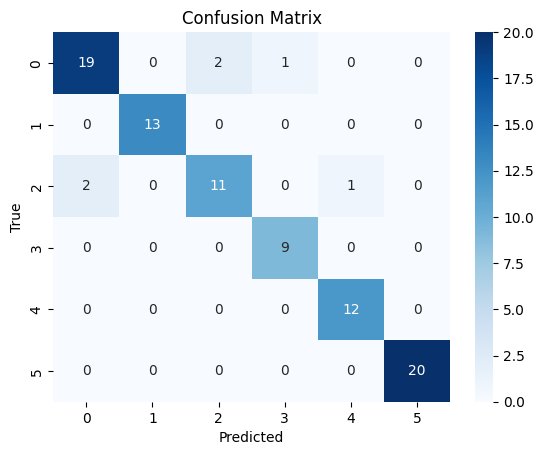

In [ ]:
# Creamos una matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizamos la matriz con seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Entrenamos también modelos basados en Naive Bayes, SVM, KNN, y DecisionTree:

In [ ]:
models = {
    "Gaussian Naive Bayes": GaussianNB(), # Add class_weight here
    "Support Vector Machine": SVC(class_weight=class_weights_dict), # Add class_weight here
    "K-Nearest Neighbors": KNeighborsClassifier(weights='distance'), # You can use weights='distance' for KNN
    "Decision Tree": DecisionTreeClassifier(class_weight=class_weights_dict), # Add class_weight here
    # ... (other models)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy}")

Gaussian Naive Bayes Accuracy: 0.5444444444444444
Support Vector Machine Accuracy: 0.4666666666666667
K-Nearest Neighbors Accuracy: 0.8555555555555555
Decision Tree Accuracy: 0.9333333333333333


Vemos que a los demás modelos no les va tan bien como a RandomForest, exceptuando a DecisionTree que tiene un desempeño similar.

Por curiosidad quise ver la correlación entre las características seleccionadas y el nivel de miedo. Vemos que no hay una correlación muy fuerte con ninguna, aunque en conjunto generan un buen resultado.

Correlation between HRV_MCVNN and fear level: -0.11490417428205356


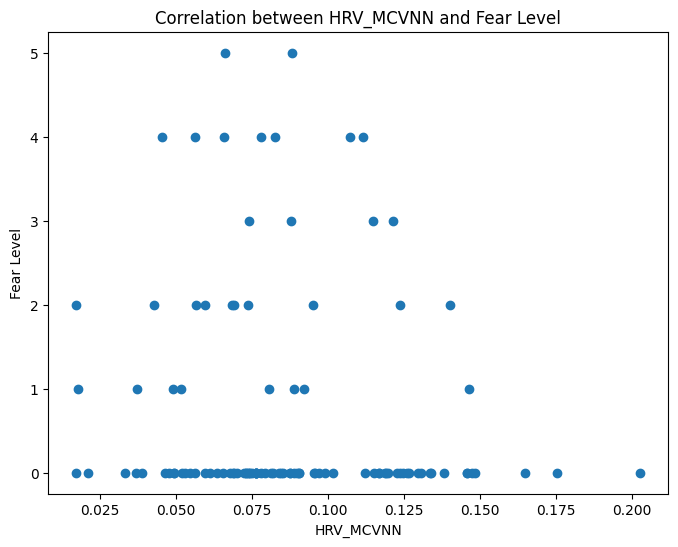

Correlation between HRV_SDRMSSD and fear level: 0.07589453848051307


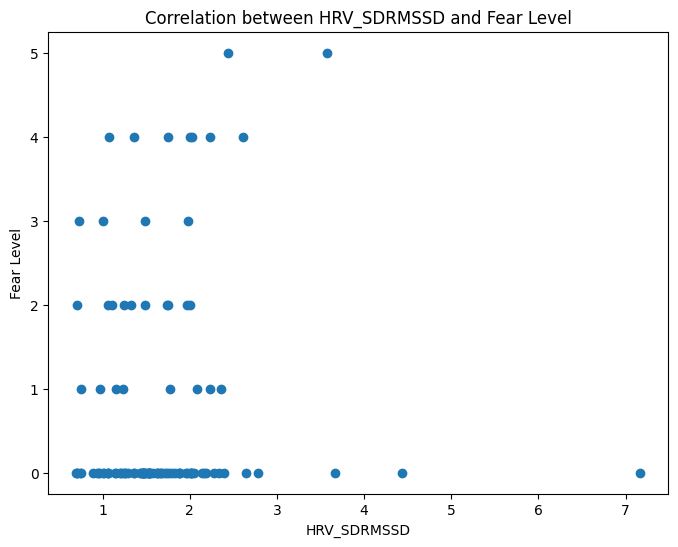

Correlation between HRV_pNN20 and fear level: -0.11429562507552425


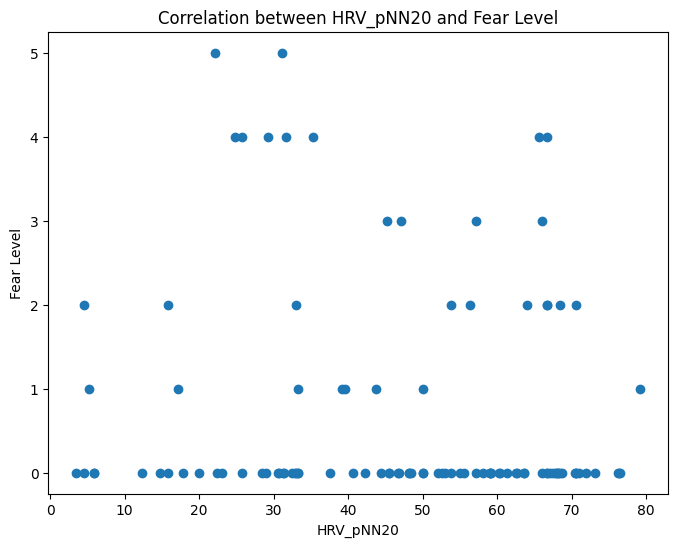

Correlation between event_type and fear level: 0.3323222115600284


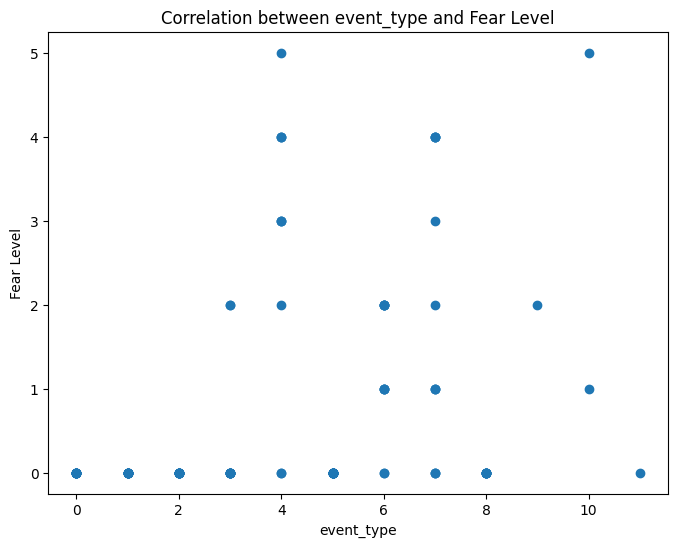

Correlation between sex and fear level: -0.19227980225461028


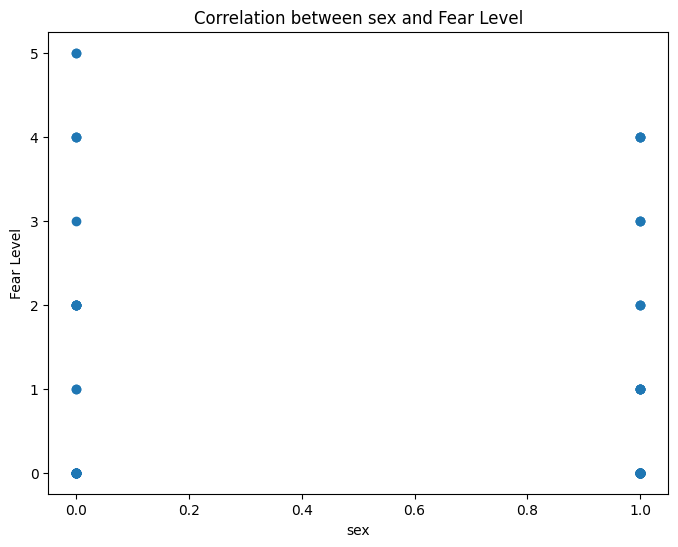

Correlation between VR experience and fear level: -0.1540772459838154


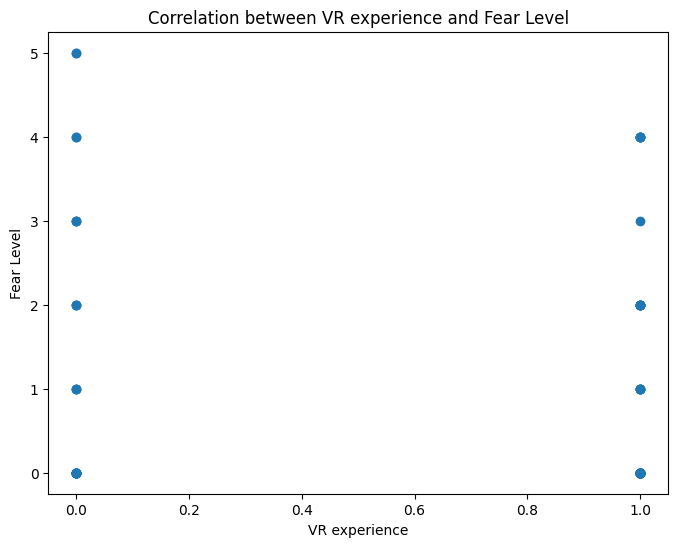

Correlation between heart/vertigo issue and fear level: -0.014088484485411652


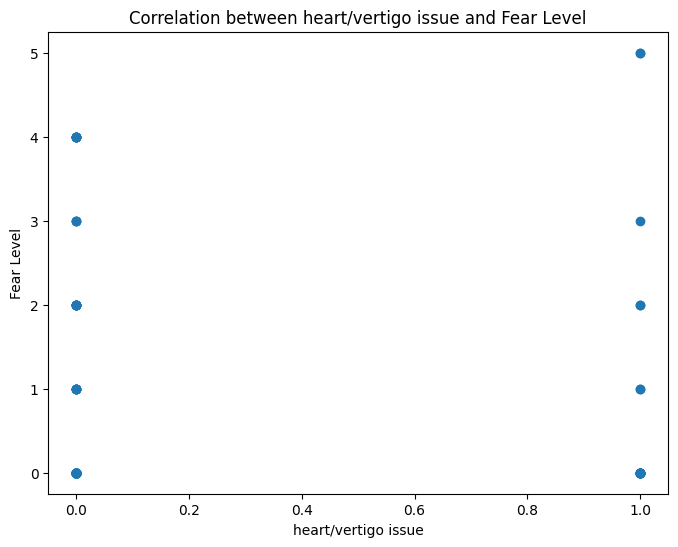

In [ ]:
for feature in selected_features:
    correlation = event_features_df[feature].corr(event_features_df['fear level'])
    print(f"Correlation between {feature} and fear level: {correlation}")

    plt.figure(figsize=(8, 6))
    plt.scatter(event_features_df[feature], event_features_df['fear level'])
    plt.xlabel(feature)
    plt.ylabel("Fear Level")
    plt.title(f"Correlation between {feature} and Fear Level")
    plt.show()


## Conclusiones

El modelo entrenado utilizando RandomForest fue el que tuvo mejor resultado, con un accuracy de 0.93 (se puede visualizar su desempeño también en la matriz de confusión). Considero que este resultado fue logrado gracias al aumento de datos con Over-sampling y gracias a la separación en eventos y correlación con series de tiempo. Con los datos crudos, dado que aproximadamente el 70% de los datos eran nivel de miedo = 0, a los modelos con mejor rendimiento tenían alrededor de 0.70 ya que simplemente catalogaban todo como nivel 0. Con un dataset balanceado como el que se logró ya se pudieron visualizar mejores puntuaciones.